# 1. Introdução

Otimização e Tuning de Hiperparâmetros
Projeto: Credit Risk – Home Credit Default Risk
Após a avaliação de diferentes estratégias de balanceamento e algoritmos de classificação, o XGBoost apresentou o melhor desempenho geral para identificação de clientes inadimplentes.

Este notebook tem como objetivo otimizar o desempenho do modelo por meio do ajuste de hiperparâmetros, validação cruzada e calibração do limiar de classificação, buscando melhorar a capacidade de identificação da classe inadimplente sem comprometer excessivamente a precisão das previsões.

# 1.  Bibliotecas

In [16]:
# MANIPULAÇÃO DE DADOS
import pandas as pd
import numpy as np

# GRÁFICOS
import matplotlib.pyplot as plt

# METRICAS DE DECISÃO e SMOTE para teste de balanceamento das classes
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, StratifiedKFold

# MACHINE LEARNING
from xgboost import XGBClassifier

# 2. Carregamento dos Dados processados

Nesta etapa são carregados os dados previamente processados e utilizados nas etapas anteriores de modelagem.

In [2]:
# Features
features_processed = pd.read_parquet('../data/processed/Features_processed.parquet')
# Target
target_processed = pd.read_parquet('../data/processed/Target_processed.parquet')
# APLICANDO A FUNÇÃO RAVEL() NOS VALORES DO TARGET PARA CONVERTER PARA UM COLUNA 1D
target_processed_corrigido = target_processed.values.ravel()

# 3. Separação em treino e teste

Os dados são divididos em conjuntos de treino e teste utilizando amostragem estratificada, preservando a proporção da variável target.

In [3]:
# DIVIDINDO OS DADOS ENTRE TREINO E TESTE
x_treino, x_teste, y_treino, y_teste = train_test_split(features_processed, target_processed_corrigido, shuffle = True, test_size = 0.3, random_state  = 0, stratify = target_processed_corrigido)

# 4. Modelo de Referência (XGBoost Atual)

Antes da otimização, será registrado o desempenho do melhor modelo obtido na etapa anterior, permitindo comparação direta com as versões otimizadas.

## 4.1 Treinamento

In [4]:
y_treino_series = pd.Series(y_treino)
print('Frequência em cada classe')
display(y_treino_series.value_counts())
print(f'Razão entre adimplente e inadimplente para utilizar como hiperparametro de scale_pos_wight:{197880 / 17377:.2f}')

Frequência em cada classe


0    197880
1     17377
Name: count, dtype: int64

Razão entre adimplente e inadimplente para utilizar como hiperparametro de scale_pos_wight:11.39


In [5]:
modelo_xgb = XGBClassifier(n_estimators = 300, random_state = 0, max_depth = 6, learning_rate = 0.05, 
                               scale_pos_weight = 11.39, eval_metric = 'logloss', n_jobs = -1)
modelo_xgb.fit(x_treino, y_treino)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [6]:
y_pred_xgb = modelo_xgb.predict(x_teste)
y_proba_xgb = modelo_xgb.predict_proba(x_teste)[:,1]
print(f'Predições feitas pelo modelo: {y_pred_xgb}')
print(f'Probabilidade das predições: {y_proba_xgb}')

Predições feitas pelo modelo: [1 1 0 ... 0 1 0]
Probabilidade das predições: [0.66382056 0.67020404 0.3313439  ... 0.44903702 0.73624986 0.39984274]


## 4.2 Classification Report

In [7]:
print(classification_report(y_teste, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.74      0.83     84806
           1       0.18      0.65      0.28      7448

    accuracy                           0.73     92254
   macro avg       0.57      0.69      0.56     92254
weighted avg       0.90      0.73      0.79     92254



## 4.3 Matriz de Confusão

In [8]:
print(confusion_matrix(y_teste, y_pred_xgb))

[[62398 22408]
 [ 2625  4823]]


## 4.4 AUC-ROC

In [9]:
print(roc_auc_score(y_teste, y_proba_xgb))

0.7583249792481447


## 4.5 Curva ROC

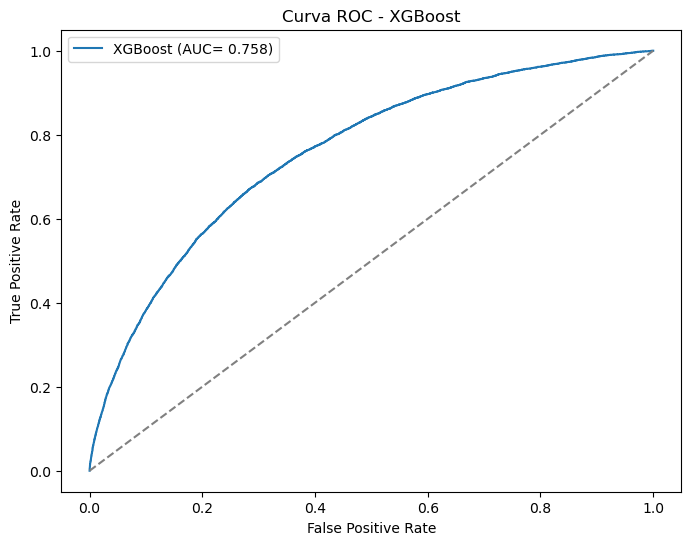

In [10]:
fpr, tpr, _ = roc_curve(
    y_teste,
    y_proba_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC= {roc_auc_score(y_teste, y_proba_xgb):.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost')

plt.show()

## 4.6 Curva Precision-Recall

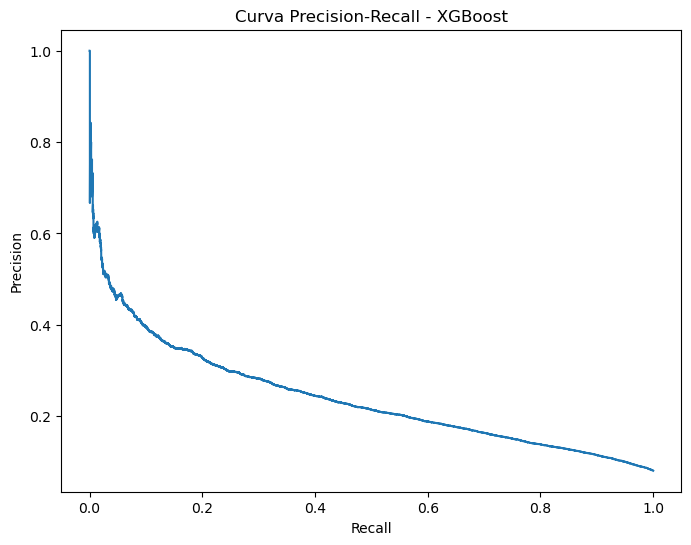

In [19]:
precision, recall, _ = precision_recall_curve(
    y_teste,
    y_proba_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Curva Precision-Recall - XGBoost')

plt.show()

## 4.7 Validação Cruzada

In [19]:
# CONFIGURANDO O KFOLD ESTRATIFICADO PARA SEPARAR AS CLASSES COMO É ORIGINAL NO DATASET 92% ADIMPLENTE E 8% INADIMPLENTE
cv_estratificado = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 0)
# DEFININDO AS METRICAS UTILIZADAS PARA MÉDOA
metricas = {'roc_auc':'roc_auc', 'precision':'precision','recall':'recall'}
# UTILIZANDO O CROSS_VALIDATE PARA RETORNAR MAIS DE 1 MÉTRICA MÉDIA
resultados = cross_validate(modelo_xgb, features_processed, target_processed_corrigido, cv = cv_estratificado, scoring = metricas, n_jobs = -1)
# EXIBINDO OS RESULTADOS DA VALIDAÇÃO CRUZADA
print(f'AUC-ROC Médio: {np.mean(resultados['test_roc_auc']):.4f}')
print(f'PRECISION Médio: {np.mean(resultados['test_precision']):.4f}')
print(f'RECALL Médio: {np.mean(resultados['test_recall']):.4f}')

AUC-ROC Médio: 0.7554
PRECISION Médio: 0.1748
RECALL Médio: 0.6402


## 4.8 Avaliação dos Resultados

A validação cruzada estratificada apresentou resultados muito próximos aos observados no conjunto de teste utilizado na avaliação do modelo de referência.

As métricas médias de AUC-ROC, Precision e Recall permaneceram consistentes, indicando que o desempenho do XGBoost não depende de maneira significativa de uma divisão específica dos dados.

Esse comportamento sugere boa capacidade de generalização do modelo e reduz o risco de que os resultados observados tenham sido obtidos por sorte ou por particularidades da amostra utilizada inicialmente.

Dessa forma, a validação cruzada reforça a confiabilidade do modelo e fornece uma base sólida para a etapa de otimização dos hiperparâmetros.

# 5. Otimização de Hiperparâmetros

## 5.1 Definição do Espaço de Busca
Para otimizar o desempenho do XGBoost, foi definido um conjunto de hiperparâmetros candidatos para exploração.

Os parâmetros selecionados possuem influência direta sobre a complexidade do modelo, capacidade de generalização e equilíbrio entre underfitting e overfitting.

A busca será realizada por meio de RandomizedSearchCV, permitindo explorar diferentes combinações de forma eficiente.

In [23]:
# INTERVALO DOS PARAMETROS QUE SERÃO UTILIZADOS NO RANDOMIZEDSEARCHCV
parametros = {

    'n_estimators': [100, 200, 300, 500],

    'max_depth': [3, 4, 5, 6, 8],

    'learning_rate': [0.01, 0.03, 0.05, 0.1],

    'subsample': [0.7, 0.8, 0.9, 1.0],

    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],

    'min_child_weight': [1, 3, 5],

    'gamma': [0, 0.1, 0.2, 0.3],
    
    'scale_pos_weight': [8,10,12,14],
    
    'eval_metric': ['logloss']
}

## 5.2 RandomizedSearchCV

In [27]:
# CRIANDO O ALGORIMO PADRÃO
xgb = XGBClassifier(random_state = 0)

# CRIANDO O RANDOM_SEARCH, O ALGORITMO UTILIZADO É O XGB, INTERVALO DE PARAMETROS DEFINIDOS NO PASSO ANTERIOR
# 30 INTERAÇÕES, PRINCIPAL METRICA DE DECISÃO BUSCADA = 'ROC_AUC'. quantidade de voltas no kfold
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=parametros,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=0,
    n_jobs=1
)

## 5.3 Melhor configuração encontrada

In [28]:
# EXECUTANDO O RANDOM_SEARCH PARA BUSCAR OS MELHORES PARAMETROS
random_search.fit(x_treino, y_treino)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=0.7, eval_metric=logloss, gamma=0, learning_rate=0.05, max_depth=8, min_child_weight=1, n_estimators=300, scale_pos_weight=14, subsample=0.7; total time=  29.1s
[CV] END colsample_bytree=0.7, eval_metric=logloss, gamma=0, learning_rate=0.05, max_depth=8, min_child_weight=1, n_estimators=300, scale_pos_weight=14, subsample=0.7; total time=  27.7s
[CV] END colsample_bytree=0.7, eval_metric=logloss, gamma=0, learning_rate=0.05, max_depth=8, min_child_weight=1, n_estimators=300, scale_pos_weight=14, subsample=0.7; total time=  20.7s
[CV] END colsample_bytree=0.9, eval_metric=logloss, gamma=0.3, learning_rate=0.03, max_depth=4, min_child_weight=5, n_estimators=300, scale_pos_weight=14, subsample=1.0; total time=  12.1s
[CV] END colsample_bytree=0.9, eval_metric=logloss, gamma=0.3, learning_rate=0.03, max_depth=4, min_child_weight=5, n_estimators=300, scale_pos_weight=14, subsample=1.0; total time=  13.2s


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'eval_metric': ['logloss'], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,0
,error_score,nan


In [29]:
# EXTRAINDO OS MELHORES PARAMETROS E O MELHOR AUC-ROC OBTIDO
melhores_parametros = random_search.best_params_
melhor_score = random_search.best_score_
print(f'Melhores parametros: {melhores_parametros}')
print(f'Melhor AUC-ROC obtido: {melhor_score:.2f}')

Melhores parametros: {'subsample': 0.9, 'scale_pos_weight': 8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.2, 'eval_metric': 'logloss', 'colsample_bytree': 1.0}
Melhor AUC-ROC obtido: 0.76


## 5.4 Avaliação do Modelo Otimizado

In [30]:
# REALIZANDO AS PREVISÕES E EXTRAINDO AS PROBABILIDADES
y_pred_random = random_search.predict(x_teste)
y_proba_random = random_search.predict_proba(x_teste)[:,1]

print(y_pred_random)
print(y_proba_random)

[1 1 0 ... 0 1 0]
[0.60402715 0.6404323  0.27630657 ... 0.3389204  0.6678469  0.29457137]


## 5.5 Classification Report

In [31]:
# 
print(classification_report(y_teste, y_pred_random))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88     84806
           1       0.20      0.54      0.30      7448

    accuracy                           0.79     92254
   macro avg       0.58      0.68      0.59     92254
weighted avg       0.89      0.79      0.83     92254



## 5.6 Matriz de Confusão

In [32]:
print(confusion_matrix(y_teste,y_pred_random))

[[69117 15689]
 [ 3407  4041]]


## 5.7 AUC-ROC

In [33]:
print(roc_auc_score(y_teste, y_proba_random))

0.760633331060291


## 5.8 Curva-ROC

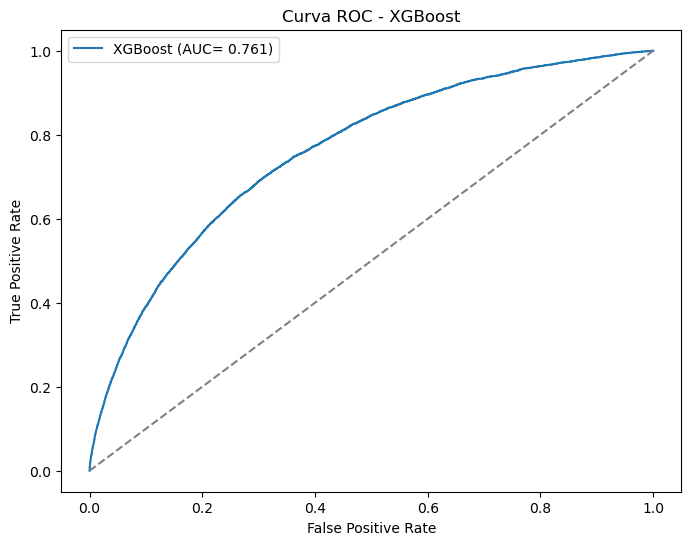

In [34]:
fpr, tpr, _ = roc_curve(
    y_teste,
    y_proba_random
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC= {roc_auc_score(y_teste, y_proba_random):.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost')

plt.show()

## 5.9 Curva Precision-Recall

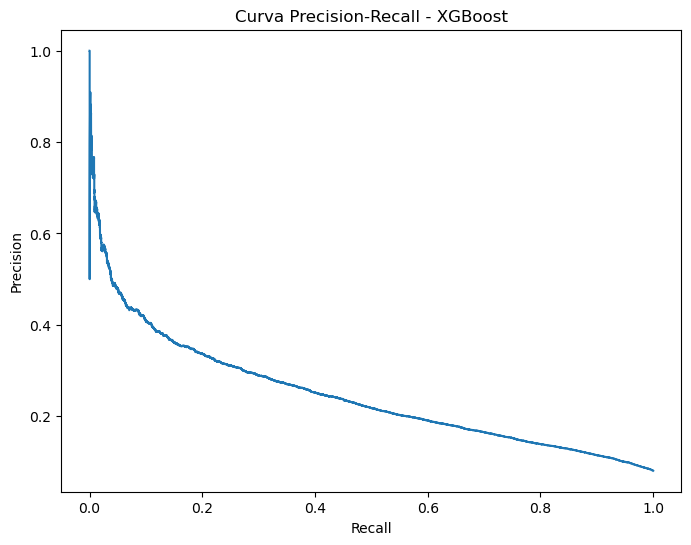

In [35]:
precision, recall, _ = precision_recall_curve(
    y_teste,
    y_proba_random
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Curva Precision-Recall - XGBoost')

plt.show()

## 6. Ajustes de Threshold de Classificação

Conforme observado anteriormente, o limiar padrão de classificação pode não representar o melhor equilíbrio entre Recall e Precision em problemas de risco de crédito.

In [47]:
# DEFINE OS LIMITE DO THRESHOLD
for threshold in [0.30, 0.35, 0.37,0.40,]:
    # CAPTURA AS PREVISÕES COM COM AS PROBABILIDADES MAIOR OU IGUAL QUE O THRESHOLD
    y_pred_custom = (y_proba_random >= threshold).astype(int)
    # PRINTA A PORCENTAGEM ATUAL
    print(f"Threshold:{threshold}")
    # EXIBE AS ESTATISTICAS OBTIDAS PELO MODELO
    print(classification_report(y_teste, y_pred_custom))
    # MATRIZ DE CONFUSÃO PARA CADA PERCENTIL
    print(confusion_matrix(y_teste, y_pred_custom))

Threshold:0.3
              precision    recall  f1-score   support

           0       0.97      0.52      0.68     84806
           1       0.13      0.83      0.23      7448

    accuracy                           0.55     92254
   macro avg       0.55      0.68      0.45     92254
weighted avg       0.90      0.55      0.64     92254

[[44158 40648]
 [ 1253  6195]]
Threshold:0.35
              precision    recall  f1-score   support

           0       0.97      0.61      0.75     84806
           1       0.15      0.76      0.25      7448

    accuracy                           0.62     92254
   macro avg       0.56      0.69      0.50     92254
weighted avg       0.90      0.62      0.71     92254

[[51833 32973]
 [ 1753  5695]]
Threshold:0.37
              precision    recall  f1-score   support

           0       0.97      0.64      0.77     84806
           1       0.15      0.74      0.26      7448

    accuracy                           0.65     92254
   macro avg       0.5

## 6.1 Ajuste do Threshold de Classificação

Após a otimização do modelo XGBoost, foram realizados testes com diferentes thresholds de classificação visando encontrar um melhor equilíbrio entre Recall e Precision para a classe inadimplente.

Observou-se que reduções moderadas no threshold aumentaram significativamente a capacidade de captura dos clientes inadimplentes, evidenciada pelo aumento do recall da classe positiva.

Entre os valores avaliados, o threshold de 0,37 apresentou o melhor equilíbrio geral para o contexto do projeto, elevando o recall da classe inadimplente para aproximadamente 74%, ao custo de uma redução moderada na precisão.

Os resultados reforçam que a escolha do threshold possui impacto direto no comportamento do modelo e deve ser definida considerando os objetivos de negócio e o custo associado aos diferentes tipos de erro.



# 7. Importância das Variáveis

A análise da importância das variáveis permite identificar quais atributos exercem maior influência sobre a previsão de inadimplência.

## 7.1 Ranking das Features

In [53]:
# VARIÁVEIS DO MAIOR PARA O MENOR, DEMONSTRANDO A SUA IMPORTÂNCIA NAS DECISÕES TOMADAS
importancia = pd.DataFrame({'Feature': x_treino.columns,
                           'Importance': random_search.best_estimator_.feature_importances_})
importancia = importancia.sort_values(by = 'Importance', ascending = False)
importancia.head(20)

,Feature,Importance
29,EXT_SOURCE_2,0.054271
30,EXT_SOURCE_3,0.041913
195,NAME_EDUCATION_TYPE_Higher education,0.029479
13,FLAG_EMP_PHONE,0.026292
194,NAME_INCOME_TYPE_Working,0.023819
177,CODE_GENDER_M,0.020779
166,AMT_REQ_CREDIT_BUREAU_HOUR_missing_flag,0.016654
190,NAME_INCOME_TYPE_Pensioner,0.016517
28,EXT_SOURCE_1,0.015639
310,RATIO_CREDIT_GOODS,0.014788


## 7.2 Visualização Gráfica

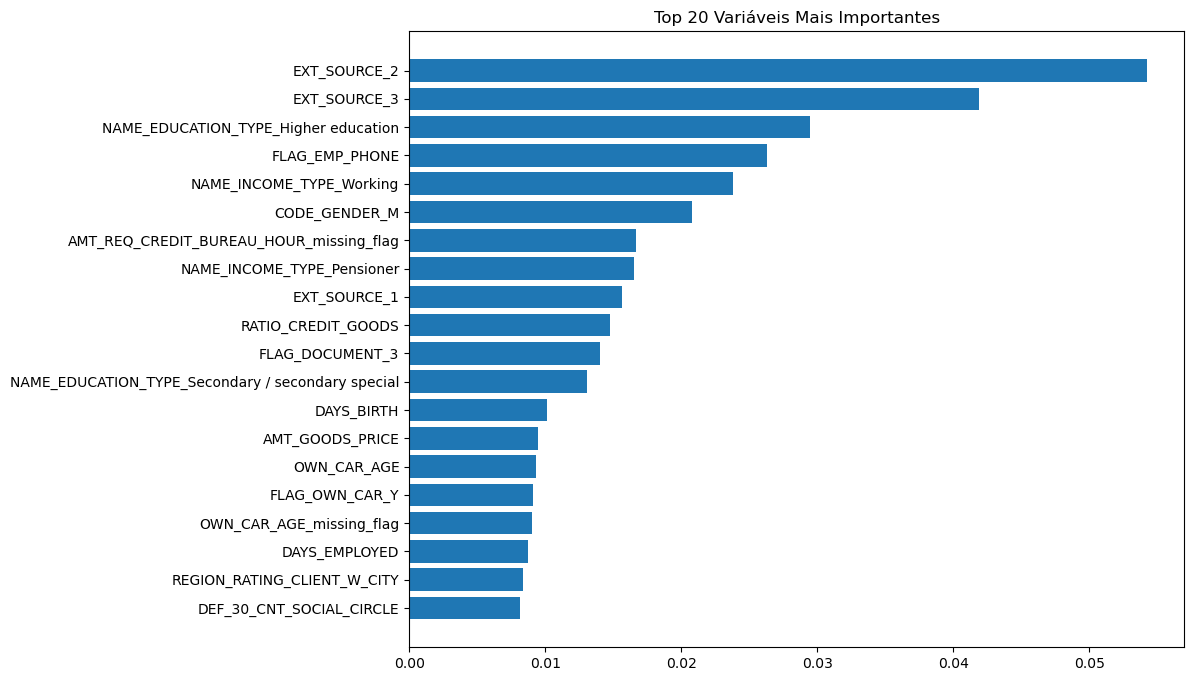

In [62]:
# ANÁLISE GRÁFICA DA IMPORTÂNCIA DAS VARIÁVEIS
top20 = importancia.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20['Feature'],
    top20['Importance']
)

plt.title('Top 20 Variáveis Mais Importantes')
plt.gca().invert_yaxis()

#plt.savefig('../data/processed/compracao_modelos.png',bbox_inches='tight',dpi=300)
#top20.savefig('../data/processed/top20_features.csv')
plt.show()



## 7.3 Interpretação

A análise de importância das variáveis mostra que os principais fatores associados à previsão de inadimplência estão relacionados a indicadores externos de risco de crédito, representados pelas variáveis EXT_SOURCE_2 e EXT_SOURCE_3, que apresentaram as maiores contribuições para o modelo.

Além dos indicadores externos, características socioeconômicas, como nível de escolaridade, tipo de renda e idade, também exerceram influência relevante na classificação dos clientes.

Observa-se ainda que variáveis derivadas e indicadores criados durante a etapa de engenharia de features, como RATIO_CREDIT_GOODS e flags de valores ausentes, apareceram entre as variáveis mais importantes do modelo, demonstrando que as transformações realizadas contribuíram para capturar informações adicionais relevantes para o risco de crédito.

Os resultados reforçam que a inadimplência é influenciada por múltiplos fatores financeiros, demográficos e comportamentais, não sendo explicada por uma única característica isolada.

# 8. Comparação Final

Comparação entre todos os modelos escolhidos e testados ao decorrer do projeto

,Modelo,Accuracy,Recall Classe 1,Precision Classe 1,AUC ROC
0,Logistic Baseline,0.92,0.00,0.00,0.630
1,Logistic + Class Weight,0.60,0.57,0.11,0.580
2,Logistic + SMOTE,0.63,0.44,0.10,0.570
3,Random Forest (Threshold = 0.10),0.73,0.59,0.17,0.730
4,XGBoost (Threshold = 0.50),0.73,0.65,0.18,0.758
5,XGBoost (Threshold = 0.37),0.65,0.74,0.15,0.758


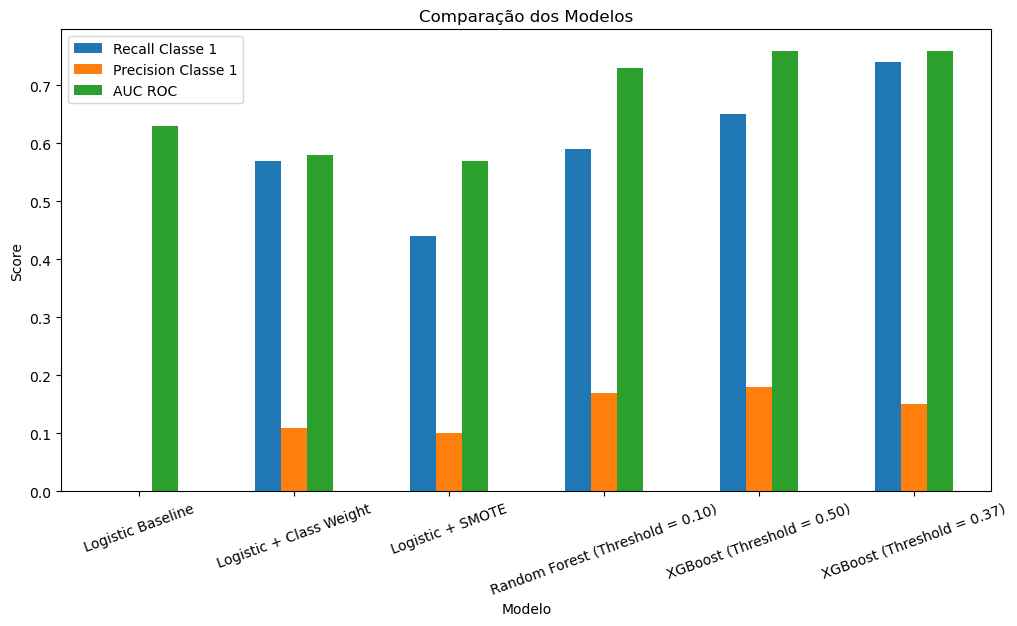

In [61]:
comparacao_final = pd.DataFrame({

    'Modelo': [
        'Logistic Baseline',
        'Logistic + Class Weight',
        'Logistic + SMOTE',
        'Random Forest (Threshold = 0.10)',
        'XGBoost (Threshold = 0.50)',
        'XGBoost (Threshold = 0.37)'
    ],

    'Accuracy': [
        0.92,
        0.60,
        0.63,
        0.73,
        0.73,
        0.65
    ],

    'Recall Classe 1': [
        0.00,
        0.57,
        0.44,
        0.59,
        0.65,
        0.74
    ],

    'Precision Classe 1': [
        0.00,
        0.11,
        0.10,
        0.17,
        0.18,
        0.15
    ],

    'AUC ROC': [
        0.63,
        0.58,
        0.57,
        0.73,
        0.758,
        0.758
    ]
})

display(comparacao_final)

comparacao_final.set_index('Modelo')[
    ['Recall Classe 1', 'Precision Classe 1', 'AUC ROC']
].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Comparação dos Modelos')
plt.ylabel('Score')
plt.xticks(rotation=20)

#plt.savefig('../data/processed/compracao_modelos.png',bbox_inches='tight',dpi=300)
#comparacao_final.savefig('../data/processed/comparacao_modelos.csv')

plt.show()



## Interpretação

A comparação dos modelos evidencia a forte influência do tratamento do desbalanceamento e da escolha do algoritmo sobre o desempenho do sistema de classificação.

O modelo baseline apresentou elevada acurácia, porém não foi capaz de identificar clientes inadimplentes, demonstrando que a acurácia isoladamente não é uma métrica adequada para este problema.

A utilização do parâmetro class_weight='balanced' promoveu aumento significativo da capacidade de identificação da classe inadimplente, evidenciando o impacto do desbalanceamento da variável target sobre o processo de treinamento.

A estratégia baseada em SMOTE não apresentou ganhos expressivos em relação ao balanceamento por ponderação das classes, resultando em desempenho inferior na identificação da classe positiva.

A Random Forest demonstrou elevada capacidade de separação entre clientes adimplentes e inadimplentes, atingindo AUC-ROC superior a 70%. Entretanto, o modelo exigiu ajuste de threshold para converter essa capacidade de ranqueamento em predições efetivas.

O XGBoost apresentou o melhor desempenho geral entre todos os modelos avaliados. Além de alcançar a maior capacidade de separação das classes, também foi o modelo que apresentou o melhor equilíbrio entre Recall, Precision e AUC-ROC.

# 9. Conclusões

O objetivo deste projeto foi desenvolver um modelo capaz de identificar clientes com maior probabilidade de inadimplência utilizando a base Home Credit Default Risk.

A análise exploratória permitiu identificar forte desbalanceamento da variável target, elevado volume de valores ausentes e padrões relevantes relacionados à renda, crédito e características socioeconômicas dos clientes.

Durante a etapa de engenharia de variáveis foram aplicadas estratégias de tratamento de valores ausentes, transformações numéricas, codificação das variáveis categóricas e criação de novas features derivadas de relações financeiras entre os clientes.

Os experimentos realizados durante a etapa de modelagem demonstraram que o desbalanceamento das classes era um dos principais fatores limitantes do desempenho dos modelos. A utilização de técnicas de balanceamento permitiu aumentar significativamente a capacidade de identificação dos clientes inadimplentes.

Entre os métodos avaliados, o XGBoost apresentou o melhor desempenho geral, atingindo aproximadamente 75,8% de capacidade de separação entre as classes (AUC-ROC) e aproximadamente 74% de recall para a classe inadimplente após o ajuste do threshold de classificação.

A análise das variáveis mais importantes demonstrou que indicadores externos de crédito, perfil socioeconômico e indicadores relacionados à exposição ao crédito possuem papel relevante na identificação do risco de inadimplência.

Os resultados obtidos mostram que o modelo desenvolvido apresenta potencial para utilização como ferramenta de apoio à análise de risco, permitindo priorizar clientes com maior probabilidade de inadimplência e apoiar processos de tomada de decisão em crédito.

# 10. Próximos Passos

- Como possíveis evoluções do projeto, destacam-se:

- Busca mais ampla de hiperparâmetros para o XGBoost utilizando técnicas avançadas de otimização.
Avaliação de estratégias adicionais de balanceamento da variável target.

- Calibração das probabilidades previstas pelo modelo.

- Estudo de métricas de negócio específicas para risco de crédito.

- Desenvolvimento de dashboard para visualização dos resultados.

- Implementação de pipeline automatizado para treinamento e monitoramento do modelo.